In [1]:
%load_ext autoreload
%autoreload 2
import os, sys

import sys
sys.path.append("../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import bisect
from tqdm import tqdm
from ipywidgets import interact
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch
import matplotlib.animation as animation

from scipy import signal

from src.fmcw_simulation.simulation import FmcwRadar
from src.py_network.adaptive_resonate import AdaptiveResonate

plt.rc('xtick',labelsize=25)
plt.rc('ytick',labelsize=25)
# mpl.rcParams['figure.dpi'] = 200 
mpl.rcParams['figure.figsize'] = (12, 9) 
mpl.rcParams['axes.titlesize'] = 30
mpl.rcParams['axes.labelsize'] = 25
mpl.rcParams['legend.fontsize'] = 20
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#003052", "#C71818", "#18C7C7", "#70C718", "#7018C7"])
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#6ba0a6", "#d8584e", "#c09651", "#f8c08a", "#8e4f39", "#2f3240"])

In [2]:
radar_config = {
    "n_rx": 1,
    "fb" : 60e9,
    "B" : 2e9,
    "n_chirps": 64,
    "n_samples": 128,
    "t_chirp": 6.4e-5,
    "IQ": True,
    "noise_std": 0.2
}
apply_hann = False

In [3]:
fmcw = FmcwRadar(config=radar_config)
fmcw.target_snr_db = 10
fmcw.random_Ap = False

# fixed targets
# targets = [
#     {
#         "range":3,
#         "velocity": 0.0,
#         "angle": np.deg2rad(0)
#     },
#     {
#         "range": 6.5,
#         "velocity": 0.0,
#         "angle": np.deg2rad(0)
#     }
# ]

# random targets
n_targets = 2
targets = []
for i in range(n_targets):
    t = {
        "range": (i+1) * ((fmcw.max_range / 2) / n_targets),
        "velocity": 0.0,
        "angle": 0.0
    }
    targets.append(t)

fmcw.set_targets(targets)
frame = fmcw.generate_data_snr()

In [4]:
if apply_hann:  
    frame = fmcw.apply_hann(frame)

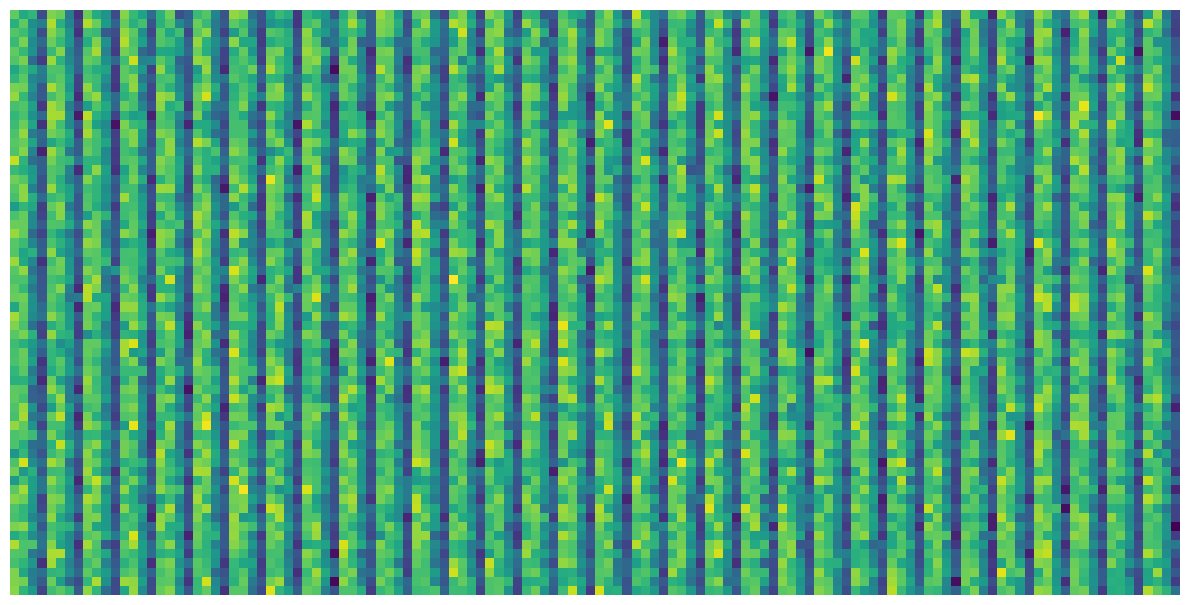

In [5]:
plt.imshow(frame[0].real, interpolation='none')
plt.ylabel("chirps")
plt.xlabel("samples")

# plt.savefig("frame_with_vel.png", bbox_inches='tight', dpi=300)

plt.axis("off")
plt.tight_layout()

plt.savefig("paper_figures/full_frame.svg", bbox_inches="tight", transparent=True)

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


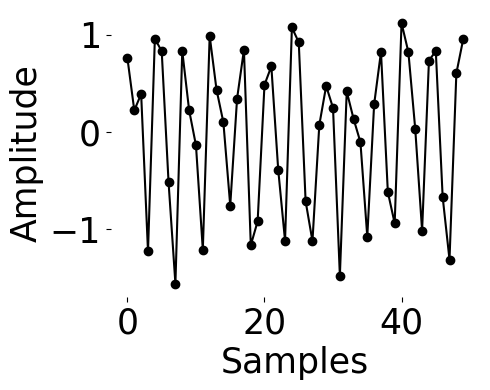

In [6]:
fig, ax = plt.subplots(1, figsize=(5, 4))
# plt.plot(fmcw.pure_signal[0, 0, :].flatten())
ax.plot(frame[0, 0, :50], c="black", marker='o')
# plt.plot(frame[0, 1, :].flatten())

# plt.axis("off")
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

ax.set_xlabel("Samples")
ax.set_ylabel("Amplitude")

plt.tight_layout()

plt.savefig("paper_figures/full_signal.svg", bbox_inches="tight", transparent=True)

In [7]:
np_fft = np.fft.fftn(frame)
np_fft = np.fft.fftshift(np_fft)
np_fft = np_fft[:, :, :]

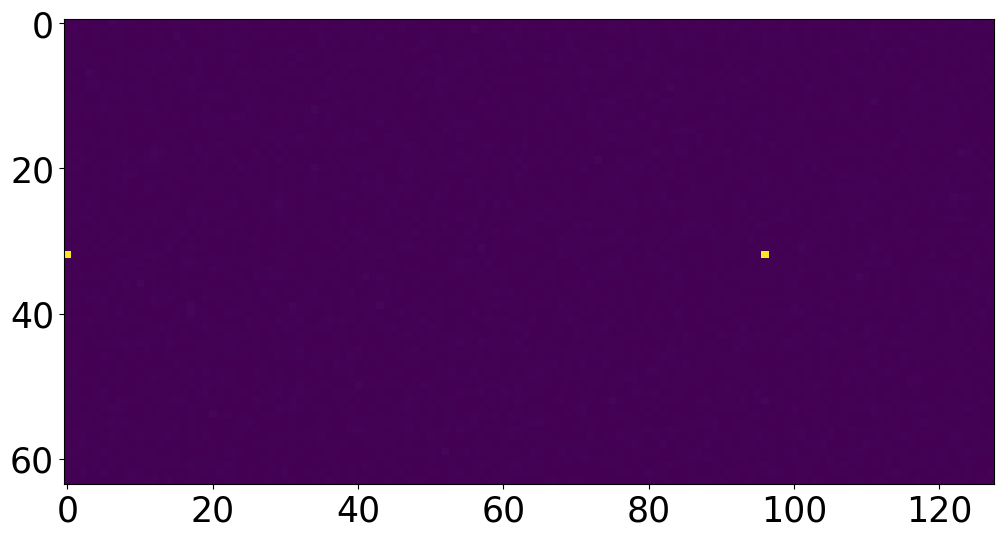

In [8]:
plt.imshow(np.abs(np_fft[0]))

In [9]:
ranges = fmcw.get_ranges()
vels = fmcw.get_velocities()
angles = fmcw.get_angles()

In [10]:
n_units = len(targets)
t_max = fmcw.t_chirp * fmcw.n_chirps
t_res = fmcw.t_chirp / fmcw.n_samples
res_net = AdaptiveResonate(
            n_units, 
            t_max, 
            fmcw.t_chirp / fmcw.n_samples, 
            k=1,
            feedback=True,
            w_scale= np.ones((fmcw.n_rx, n_units))*t_res*100*0.8,
            n_rxs=fmcw.n_rx
)

# res_net.spike_condition = res_net.period_spiking
res_net.normalize_input = False
res_net.normalize_neuron = True
res_net.alpha_lpf = 1.0

res_net.wdot_mode = False

sampling_rate = fmcw.n_samples / fmcw.t_chirp
max_start_freq = sampling_rate / 4

for rx in range(fmcw.n_rx):
    max_range = fmcw.max_range - fmcw.max_range / 4
    # start_ranges = ((np.linspace(2.0, max_range, res_net.nfreq)))
    start_ranges = np.random.rand(res_net.nfreq)*(max_range - 2.0) + 2.0
    
    start_freqs = fmcw.get_freq_from_range(start_ranges)
    print(start_ranges)
    res_net.ws[:] = start_freqs * 2 * np.pi
    
res_net.periods = ((2 * np.pi) / (res_net.ws * res_net.t_res)).astype(int)

[5.30999423 6.72574345]


In [11]:
frames_to_use = 1
ws_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units))
vs_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units), dtype=complex)

if apply_hann:
    frame = fmcw.apply_hann(frame)
flat_frame = frame.reshape((frame.shape[0], -1))

for f in tqdm(range(frames_to_use)):
    
    if f > 0:
        frame = fmcw.generate_data_snr()
        if apply_hann:
            frame = fmcw.apply_hann(frame)
        flat_frame = frame.reshape((frame.shape[0], -1))

    vs_hist_tmp, ws_hist_tmp = res_net.update_neurons_c(flat_frame)

    ws_hist[f*res_net.n_steps:(f+1)*res_net.n_steps] = ws_hist_tmp
    vs_hist[f*res_net.n_steps:(f+1)*res_net.n_steps] = vs_hist_tmp

100%|██████████| 1/1 [00:00<00:00, 872.90it/s]


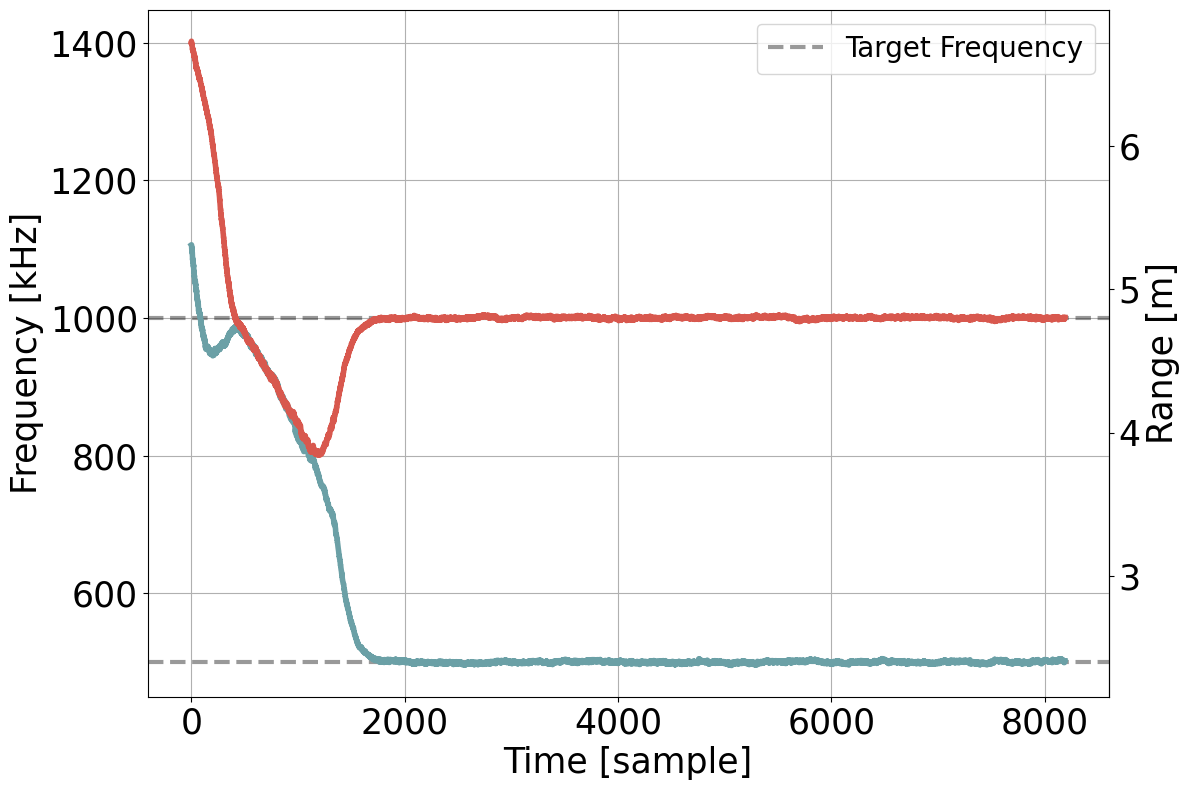

In [12]:
sig, ax = plt.subplots(figsize=(12, 8))
a = 0
gt_lwidth = 3
lwidth = 4.0
factor = 1e3


f = fmcw.get_freq_from_range(targets[0]['range']) / factor
ax.axhline(f, c="black", alpha=0.4, label="Target Frequency", linewidth=gt_lwidth, linestyle="--")
for t in targets[1:]:
    f = fmcw.get_freq_from_range(t['range']) / factor
    ax.axhline(f, c="black", alpha=0.4, linewidth=gt_lwidth, linestyle="--")

ws_hist = fmcw.get_freq_from_range(fmcw.get_range_from_freq(ws_hist/(2*np.pi)))
ax.plot(ws_hist[a:, 0, :].squeeze() / factor, linewidth=lwidth)

ax.legend()
ax.set_xlabel("Time [sample]")
ax.set_ylabel("Frequency [kHz]")
# ax.set_title("Adaptive Oscillators Dynamics")

chirp_ticks_vals = [0, 16, 32, 48, 64]
locs = [val * fmcw.n_samples for val in chirp_ticks_vals]

secay = ax.secondary_yaxis(
    'right',
    functions=(
        lambda x: fmcw.get_range_from_freq(x * factor, negative=True),  # kHz → cm
        lambda x: fmcw.get_freq_from_range(x) * factor**-1   # m → kHz (inverse)
    )
)
secay.set_ylabel("Range [m]")
ax.grid()

plt.tight_layout()

plt.savefig("paper_figures/six_targets_example.pdf", bbox_inches='tight')

In [13]:
ws_range = fmcw.get_range_from_freq(ws_hist[-1]).squeeze()[::-1]
ws_range

array([4.80430984, 2.40805474])

In [14]:
gt_ranges = [t['range'] for t in targets]
gt_ranges

[2.4, 4.8]

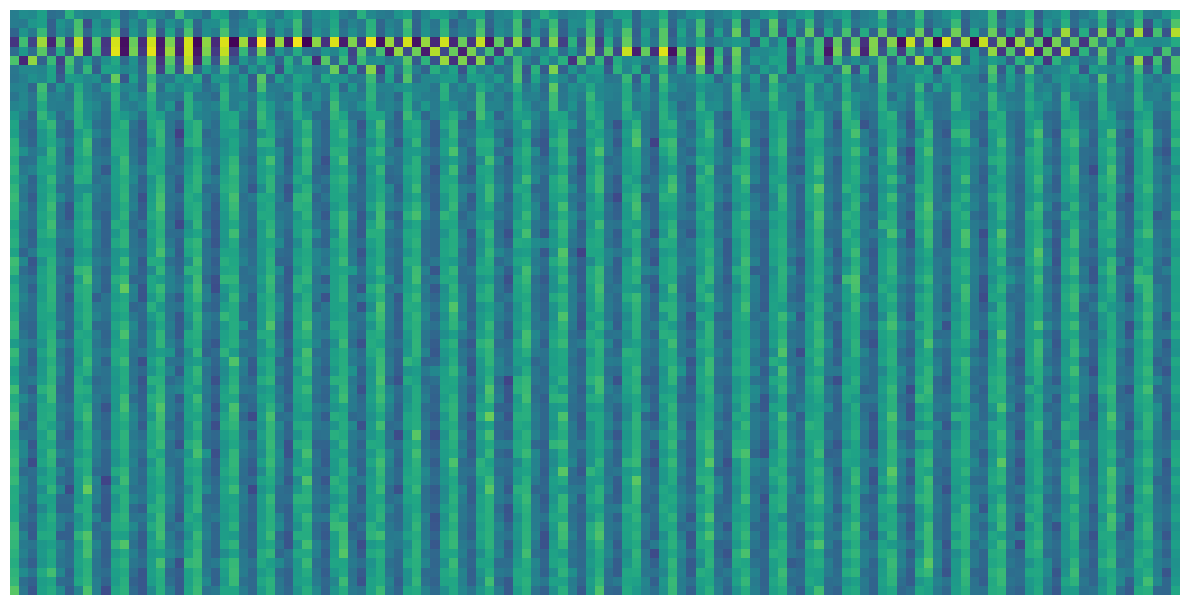

In [15]:
vs_frame = vs_hist[:,:,0].reshape(frame.shape).squeeze()
plt.imshow(vs_frame.real)
plt.axis("off")
plt.tight_layout()

plt.savefig("paper_figures/decomposed_frame1.svg", bbox_inches="tight", transparent=True)

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


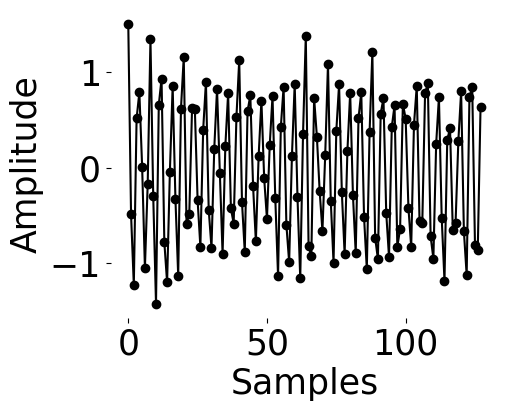

In [16]:
fig, ax = plt.subplots(1, figsize=(5, 4))
# plt.plot(fmcw.pure_signal[0, 0, :].flatten())
ax.plot(vs_frame[-1], c="black", marker='o')
# plt.plot(frame[0, 1, :].flatten())

# plt.axis("off")
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

ax.set_xlabel("Samples")
ax.set_ylabel("Amplitude")

plt.savefig("paper_figures/decomposed_signal1.svg", bbox_inches="tight", transparent=True)

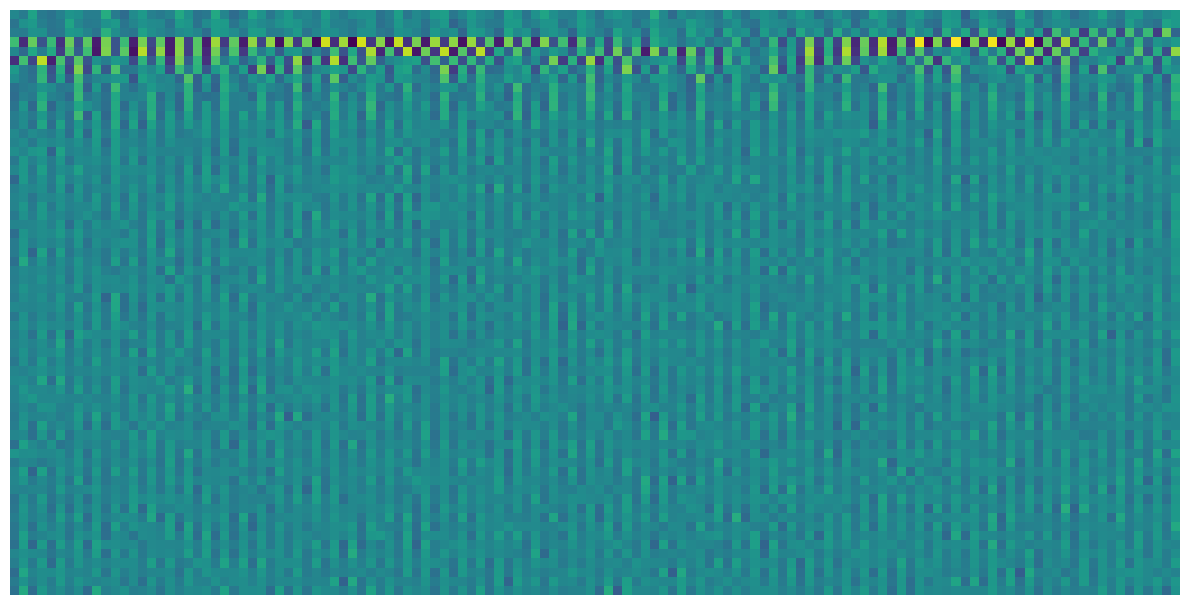

In [17]:
vs_frame = vs_hist[:,:,1].reshape(frame.shape).squeeze()
plt.imshow(vs_frame.real)
plt.axis("off")
plt.tight_layout()

plt.savefig("paper_figures/decomposed_frame2.svg", bbox_inches="tight", transparent=True)

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


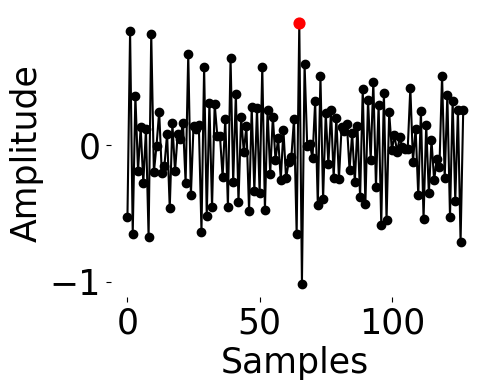

In [18]:
fig, ax = plt.subplots(1, figsize=(5, 4))
# plt.plot(fmcw.pure_signal[0, 0, :].flatten())
ax.plot(vs_frame[-1], c="black", marker='o', zorder=1)
# plt.plot(frame[0, 1, :].flatten())
ax.scatter(vs_frame[-1].size // 2 + 1, vs_frame[-1, vs_frame[-1].size // 2 + 1], 
           c="red", 
           zorder=10,
           s=60)

# plt.axis("off")
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

ax.set_xlabel("Samples")
ax.set_ylabel("Amplitude")

plt.tight_layout()

plt.savefig("paper_figures/decomposed_signal2.svg", bbox_inches="tight", transparent=True)